# BT-UNet
Self-supervised pretraining of the U-Net encoder using Barlow Twins, followed by supervised fine-tuning for segmentation across multiple label fractions.

**Pipeline:**
1. Pretrain the U-Net encoder with Barlow Twins (no labels needed)
2. Attach the decoder and fine-tune for segmentation at each label fraction (5%, 10%, 20%, 50%)

## Configuration

In [1]:
# ============================================================
# CONFIGURATION
# ============================================================
# Change paths depending on dataset

DATASET_NAME = "ISIC2018"

DATASET_CONFIGS = {
    "KDSB": {
        "train_path": "datasets/KDSB/train/",
        "val_path":   "datasets/KDSB/val/",       # doesn't exist for KDSB -> HAS_VAL will be False
        "test_path":  "datasets/KDSB/test/",
        "img_dir":    "org",             # subfolder holding images, relative to each split path
        "mask_dir":   "gt",              # subfolder holding masks, relative to each split path
        "mask_name":  lambda img_name: img_name,
    },
       "ISIC2018": {
        "train_path": "datasets/ISIC2018/train/",
        "val_path":   "datasets/ISIC2018/val/",
        "test_path":  "datasets/ISIC2018/test/",
        "img_dir":    "org",
        "mask_dir":   "gt",
        "mask_name":  lambda img_name: os.path.splitext(img_name)[0] + "_segmentation.png",
    },
}

cfg = DATASET_CONFIGS[DATASET_NAME]
TRAIN_PATH   = cfg["train_path"]
VAL_PATH     = cfg["val_path"]
TEST_PATH    = cfg["test_path"]
IMG_DIR      = cfg["img_dir"]
MASK_DIR     = cfg["mask_dir"]
mask_name_fn = cfg["mask_name"]


SAVE_DIR     = "saved_models"
SAVE_NP      = "saved_np"

IMG_HEIGHT   = 256
IMG_WIDTH    = 256
IMG_CHANNELS = 3

# Label fractions to sweep during fine-tuning
LABEL_FRACTIONS = [0.05, 0.10, 0.20, 0.50]

val_split  = 0.3
THRESHOLD  = 0.5

# Barlow Twins pretraining
PRETRAIN_EPOCHS    = 100
PRETRAIN_BATCH     = 8
PROJECT_DIM        = IMG_HEIGHT // 2
WEIGHT_DECAY       = 5e-4
PRETRAIN_FLG       = False   # False = load saved weights
PRETRAINED_WEIGHTS = f"{DATASET_NAME}_barlow_twins_encoder.keras"

# Segmentation fine-tuning
FINETUNE_EPOCHS = 200
FINETUNE_BATCH  = 8
TRAIN_FLG       = True      # False = skip fine-tuning

# TEST_MODE: set True to smoke-test the full pipeline cheaply
TEST_MODE = False

# ---- K-Fold Cross-Validation ----
USE_KFOLD       = True   # False = skip CV, only run the single train/val/test split below
N_FOLDS         = 5      # number of folds per label fraction
CV_RANDOM_STATE = 42


## Imports

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"   # must be set BEFORE tensorflow is imported
import random
import datetime
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

from skimage.io import imread, imshow
from skimage.morphology import label
from skimage.transform import resize
from sklearn.model_selection import KFold

import tensorflow as tf
from tensorflow.keras import layers, backend as K
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import *
from tensorflow.keras.metrics import Accuracy, Precision, Recall, MeanIoU, MeanAbsoluteError
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import binary_crossentropy, categorical_crossentropy
from tensorflow.python.ops import array_ops
from hausdorff import hausdorff_distance

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(SAVE_NP,  exist_ok=True)
os.makedirs("logs/fit", exist_ok=True)


I0000 00:00:1786434713.782208 2470318 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# GPU pin moved into the imports cell above — setting CUDA_VISIBLE_DEVICES
# after TensorFlow is imported has no effect.


In [4]:
# ============================================================
# GPU CONFIGURATION / DIAGNOSTICS
# ============================================================
import subprocess

# 1. Confirm the GPU is visible to the OS/driver level
try:
    print(subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout)
except FileNotFoundError:
    print('nvidia-smi not found — NVIDIA driver may not be installed/visible on this machine.')

# 2. Confirm TensorFlow itself can see the GPU
gpus = tf.config.list_physical_devices('GPU')
print(f'TensorFlow build info: {tf.sysconfig.get_build_info().get("cuda_version", "n/a")=} '
      f'{tf.sysconfig.get_build_info().get("cudnn_version", "n/a")=}')
print('TensorFlow version:', tf.__version__)
print('GPUs visible to TensorFlow:', gpus)

if gpus:
    # Prevent TF from grabbing all GPU memory upfront — safer on shared/virtual GPUs
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(e)
    print(f'Memory growth enabled on {len(gpus)} GPU(s). Training will use the GPU automatically.')
else:
    print(
        'No GPU detected by TensorFlow. If nvidia-smi above shows a GPU but this list is empty, '
        'the installed TensorFlow build likely lacks CUDA support. Fix with:\n'
        '  pip uninstall tensorflow -y\n'
        '  pip install tensorflow[and-cuda]\n'
        'Then restart the kernel and re-run this cell.'
    )

Tue Aug 11 19:51:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.173.02             Driver Version: 580.173.02     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Quadro RTX 6000                Off |   00000000:01:00.0 Off |                  Off |
| 35%   53C    P8             31W /  260W |   23041MiB /  24576MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Data Loading

In [5]:
# ---- Detect whether this dataset ships a dedicated validation split ----
HAS_VAL = os.path.isdir(os.path.join(VAL_PATH, IMG_DIR))
print(f"Validation folder found at {VAL_PATH} — will use it for validation."
      if HAS_VAL else
      "No validation folder found — will fall back to splitting train data (val_split).")

x_train_path = os.path.join(SAVE_NP, f"{DATASET_NAME}_X_train_{IMG_HEIGHT}x{IMG_WIDTH}.npy")
y_train_path = os.path.join(SAVE_NP, f"{DATASET_NAME}_Y_train_{IMG_HEIGHT}x{IMG_WIDTH}.npy")
x_test_path  = os.path.join(SAVE_NP, f"{DATASET_NAME}_X_test_{IMG_HEIGHT}x{IMG_WIDTH}.npy")
y_test_path  = os.path.join(SAVE_NP, f"{DATASET_NAME}_Y_test_{IMG_HEIGHT}x{IMG_WIDTH}.npy")

if HAS_VAL:
    x_val_path = os.path.join(SAVE_NP, f"{DATASET_NAME}_X_val_{IMG_HEIGHT}x{IMG_WIDTH}.npy")
    y_val_path = os.path.join(SAVE_NP, f"{DATASET_NAME}_Y_val_{IMG_HEIGHT}x{IMG_WIDTH}.npy")

required_paths = [x_train_path, y_train_path, x_test_path, y_test_path]
if HAS_VAL:
    required_paths += [x_val_path, y_val_path]

def load_split(split_path):
    """Load and resize one split's images + masks using this dataset's naming convention."""
    ids = next(os.walk(os.path.join(split_path, IMG_DIR)))[2][:]
    X = np.zeros((len(ids), IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.float32)
    Y = np.zeros((len(ids), IMG_HEIGHT, IMG_WIDTH, 1),            dtype=np.float32)

    for n, id_ in tqdm(enumerate(ids), total=len(ids)):
        img = imread(os.path.join(split_path, IMG_DIR, id_))[:, :, :IMG_CHANNELS]
        img = resize(img, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)
        X[n] = img

        mask = imread(os.path.join(split_path, MASK_DIR, mask_name_fn(id_)))
        mask = np.expand_dims(mask, axis=-1)
        mask = resize(mask, (IMG_HEIGHT, IMG_WIDTH, 1), mode='constant', preserve_range=True)
        Y[n][mask[:, :, 0] / 255 > 0.] = 1.

    return X, Y

if all(os.path.exists(p) for p in required_paths):
    print("Found cached arrays, loading...")
    X_train = np.load(x_train_path)
    Y_train = np.load(y_train_path)
    X_test  = np.load(x_test_path)
    Y_test  = np.load(y_test_path)
    if HAS_VAL:
        X_val = np.load(x_val_path)
        Y_val = np.load(y_val_path)
        print(f"Loaded — Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
    else:
        X_val, Y_val = None, None
        print(f"Loaded — Train: {X_train.shape}, Test: {X_test.shape}")

else:
    print("No cached arrays found, loading and resizing from disk...")

    X_train, Y_train = load_split(TRAIN_PATH)
    X_test,  Y_test  = load_split(TEST_PATH)
    print(f"Train images: {X_train.shape[0]}, Test images: {X_test.shape[0]}")

    np.save(x_train_path, X_train)
    np.save(y_train_path, Y_train)
    np.save(x_test_path,  X_test)
    np.save(y_test_path,  Y_test)

    if HAS_VAL:
        X_val, Y_val = load_split(VAL_PATH)
        print(f"Val images: {X_val.shape[0]}")
        np.save(x_val_path, X_val)
        np.save(y_val_path, Y_val)
        print(f"Saved — Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
    else:
        X_val, Y_val = None, None
        print(f"Saved — Train: {X_train.shape}, Test: {X_test.shape}")

Validation folder found at datasets/ISIC2018/val/ — will use it for validation.
Found cached arrays, loading...
Loaded — Train: (2594, 256, 256, 3), Val: (100, 256, 256, 3), Test: (1000, 256, 256, 3)


## U-Net Architecture
Identical to SimSiam-UNet and baseline UNet notebooks.

In [6]:
def double_conv_layer(x, filter_size, size, dropout, batch_norm=False, prefix="dec"):
    axis = 3
    conv = SeparableConv2D(size, (filter_size, filter_size), padding='same',
                            name=f'{prefix}_sepconv_a')(x)
    if batch_norm:
        conv = BatchNormalization(axis=axis, name=f'{prefix}_bn_a')(conv)
    conv = Activation('relu', name=f'{prefix}_relu_a')(conv)
    conv = SeparableConv2D(size, (filter_size, filter_size), padding='same',
                            name=f'{prefix}_sepconv_b')(conv)
    if batch_norm:
        conv = BatchNormalization(axis=axis, name=f'{prefix}_bn_b')(conv)
    conv = Activation('relu', name=f'{prefix}_relu_b')(conv)
    if dropout > 0:
        conv = Dropout(dropout, name=f'{prefix}_drop')(conv)
    shortcut = Conv2D(size, kernel_size=(1, 1), padding='same', name=f'{prefix}_shortcut')(x)
    if batch_norm:
        shortcut = BatchNormalization(axis=axis, name=f'{prefix}_shortcut_bn')(shortcut)
    return add([shortcut, conv], name=f'{prefix}_add')


def encoder(inputs, prefix="enc"):
    num_filters = [16, 32, 64, 128]
    skip_connections = []
    x = inputs
    for i, f in enumerate(num_filters):
        stage = f'{prefix}_stage{i}'
        a = double_conv_layer(x, 3, f, 0.1, True, prefix=stage)
        skip_connections.append(a)
        x = MaxPooling2D(pool_size=(2, 2), name=f'{stage}_pool')(a)
    return x, skip_connections


def bottleneck(inputs, prefix="bneck"):
    return double_conv_layer(inputs, 3, 256, 0.1, True, prefix=prefix)


def decoder(inputs, skip_connections, prefix="dec"):
    num_filters = [128, 64, 32, 16]
    skip_connections = skip_connections[::-1]
    x = inputs
    for i, f in enumerate(num_filters):
        stage = f'{prefix}_stage{i}'
        x_up  = UpSampling2D(size=(2, 2), data_format="channels_last", name=f'{stage}_up')(x)
        x_att = concatenate([x_up, skip_connections[i]], axis=-1, name=f'{stage}_concat')
        x     = double_conv_layer(x_att, 3, f, 0.1, True, prefix=stage)
    return x


def output(inputs, prefix="out"):
    x = Conv2D(1, kernel_size=(1, 1), name=f'{prefix}_conv')(inputs)
    x = BatchNormalization(name=f'{prefix}_bn')(x)
    x = Activation('sigmoid', name=f'{prefix}_sigmoid')(x)
    return x


## Barlow Twins Pretraining

**How Barlow Twins works:**
Two augmented views of the same image pass through the shared encoder.
The cross-correlation matrix between the two embeddings is pushed toward the identity — the diagonal toward 1 (invariance) and the off-diagonal toward 0 (redundancy reduction). No negative pairs or momentum encoder needed.

### Augmentation Pipeline

In [7]:
CROP_TO = IMG_HEIGHT
AUTO    = tf.data.AUTOTUNE
SEED    = 42

def random_resize_crop(image, scale=[0.75, 1.0], crop_size=128):
    image_shape = crop_size
    image = tf.image.resize(image, (image_shape, image_shape))
    size  = tf.random.uniform(shape=(1,), minval=scale[0]*image_shape,
                              maxval=scale[1]*image_shape, dtype=tf.float32)
    size  = tf.cast(size, tf.int32)[0]
    crop  = tf.image.random_crop(image, (size, size, 3))
    return tf.image.resize(crop, (crop_size, crop_size))

def flip_random_crop(image):
    image = tf.image.random_flip_left_right(image)
    return random_resize_crop(image, crop_size=CROP_TO)

def color_jitter(x, strength=0.5):
    x = tf.image.random_brightness(x, max_delta=0.8 * strength)
    x = tf.image.random_contrast(x, lower=1-0.8*strength, upper=1+0.8*strength)
    x = tf.image.random_saturation(x, lower=1-0.8*strength, upper=1+0.8*strength)
    x = tf.image.random_hue(x, max_delta=0.2 * strength)
    return tf.clip_by_value(x, 0, 255)

def random_apply(func, x, p):
    return func(x) if tf.random.uniform([], 0, 1) < p else x

def custom_augment(image):
    image = tf.cast(image, tf.float32)
    image = flip_random_crop(image)
    image = random_apply(lambda x: tf.image.rot90(x), image, p=0.5)
    image = random_apply(color_jitter, image, p=0.8) 
    # CHANGE: changed official github implementation to add this line,
    # because SimSiam performed better with color jitter and want consistency 
    # (Original had 0.9, but our simsiam has 0.8 and we want consistency)
    return image

ssl_ds_one = (
    tf.data.Dataset.from_tensor_slices(X_train)
    .shuffle(1024, seed=SEED)
    .map(custom_augment, num_parallel_calls=AUTO)
    .batch(PRETRAIN_BATCH)
    .prefetch(AUTO)
)
ssl_ds_two = (
    tf.data.Dataset.from_tensor_slices(X_train)
    .shuffle(1024, seed=SEED)
    .map(custom_augment, num_parallel_calls=AUTO)
    .batch(PRETRAIN_BATCH)
    .prefetch(AUTO)
)
ssl_ds = tf.data.Dataset.zip((ssl_ds_one, ssl_ds_two))


I0000 00:00:1786434716.464012 2470318 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22798 MB memory:  -> device: 0, name: Quadro RTX 6000, pci bus id: 0000:21:00.0, compute capability: 7.5


### LR Schedule (WarmUp + Cosine Decay)
Identical to SimSiam-UNet notebook.

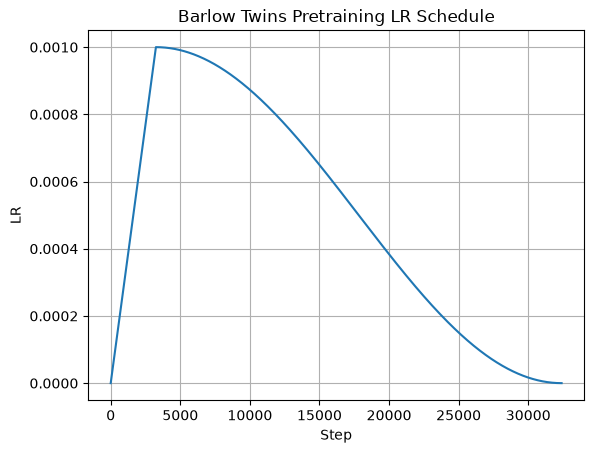

In [8]:
class WarmUpCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, learning_rate_base, total_steps, warmup_learning_rate, warmup_steps):
        super().__init__()
        self.learning_rate_base   = learning_rate_base
        self.total_steps          = total_steps
        self.warmup_learning_rate = warmup_learning_rate
        self.warmup_steps         = warmup_steps
        self.pi                   = tf.constant(np.pi)

    def __call__(self, step):
        if self.total_steps < self.warmup_steps:
            raise ValueError("total_steps must be >= warmup_steps")
        lr = (0.5 * self.learning_rate_base *
              (1 + tf.cos(self.pi * (tf.cast(step, tf.float32) - self.warmup_steps)
                          / float(self.total_steps - self.warmup_steps))))
        if self.warmup_steps > 0:
            slope       = (self.learning_rate_base - self.warmup_learning_rate) / self.warmup_steps
            warmup_rate = slope * tf.cast(step, tf.float32) + self.warmup_learning_rate
            lr          = tf.where(step < self.warmup_steps, warmup_rate, lr)
        return tf.where(step > self.total_steps, 0.0, lr)


STEPS_PER_EPOCH = len(X_train) // PRETRAIN_BATCH
TOTAL_STEPS     = STEPS_PER_EPOCH * PRETRAIN_EPOCHS
WARMUP_STEPS    = int(PRETRAIN_EPOCHS * 0.1) * STEPS_PER_EPOCH

lr_decayed_fn = WarmUpCosine(
    learning_rate_base=1e-3,
    total_steps=TOTAL_STEPS,
    warmup_learning_rate=0.0,
    warmup_steps=WARMUP_STEPS,
)

plt.plot(lr_decayed_fn(tf.range(TOTAL_STEPS, dtype=tf.float32)))
plt.title("Barlow Twins Pretraining LR Schedule")
plt.xlabel("Step")
plt.ylabel("LR")
plt.grid()
plt.show()


### Encoder + Projection Head

In [9]:
def projection_head(x, hidden_dim=128):
    for i in range(2):
        x = Dense(hidden_dim, kernel_regularizer=l2(WEIGHT_DECAY),
                  name=f"projection_layer_{i}")(x)
        x = BatchNormalization()(x)
        x = Activation("relu")(x)
    x = Dense(hidden_dim, name="projection_output")(x)
    return x

def build_encoder(shape, hidden_dim=128):
    inputs = Input(shape)
    s = layers.Rescaling(1.0 / 255)(inputs)
    x, skip_connections = encoder(s)
    x = bottleneck(x)
    trunk_output       = GlobalAvgPool2D()(x)
    projection_outputs = projection_head(trunk_output, hidden_dim=hidden_dim)
    model = Model(inputs, projection_outputs, name="bt_encoder")
    return model

unet_enc = build_encoder((IMG_WIDTH, IMG_HEIGHT, IMG_CHANNELS), hidden_dim=PROJECT_DIM)
unet_enc.summary()


Model: "bt_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 256, 256,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage0_sepconv… │ (None, 256, 256,  │         91 │ rescaling[0][0]   │
│ (SeparableConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage0_bn_a     │ (None, 256, 256,  │         64 │ enc_stage0_sepco… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage0_relu_a   │ (None, 256, 256,  │          0 │ enc_stage0_bn_a[… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage0_sepconv… │ (None, 256, 256,  │        416 │ enc_stage0_relu_… │
│ (SeparableConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage0_bn_b     │ (None, 256, 256,  │         64 │ enc_stage0_sepco… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage0_shortcut │ (None, 256, 256,  │         64 │ rescaling[0][0]   │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage0_relu_b   │ (None, 256, 256,  │          0 │ enc_stage0_bn_b[… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage0_shortcu… │ (None, 256, 256,  │         64 │ enc_stage0_short… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage0_drop     │ (None, 256, 256,  │          0 │ enc_stage0_relu_… │
│ (Dropout)           │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage0_add      │ (None, 256, 256,  │          0 │ enc_stage0_short… │
│ (Add)               │ 16)               │            │ enc_stage0_drop[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage0_pool     │ (None, 128, 128,  │          0 │ enc_stage0_add[0… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage1_sepconv… │ (None, 128, 128,  │        688 │ enc_stage0_pool[… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage1_bn_a     │ (None, 128, 128,  │        128 │ enc_stage1_sepco… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage1_relu_a   │ (None, 128, 128,  │          0 │ enc_stage1_bn_a[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage1_sepconv… │ (None, 128, 128,  │      1,344 │ enc_stage1_relu_

 Total params: 255,467 (997.92 KB)

 Trainable params: 251,979 (984.29 KB)

 Non-trainable params: 3,488 (13.62 KB)

### Barlow Twins Model

In [10]:
def off_diagonal(x):
    n = tf.shape(x)[0]
    flattened = tf.reshape(x, [-1])[:-1]
    off_diagonals = tf.reshape(flattened, (n-1, n+1))[:, 1:]
    return tf.reshape(off_diagonals, [-1])

def normalize_repr(z):
    return (z - tf.reduce_mean(z, axis=0)) / tf.math.reduce_std(z, axis=0)

def compute_loss(z_a, z_b, lambd):
    batch_size = tf.cast(tf.shape(z_a)[0], z_a.dtype)
    z_a_norm = normalize_repr(z_a)
    z_b_norm = normalize_repr(z_b)
    c = tf.matmul(z_a_norm, z_b_norm, transpose_a=True) / batch_size
    on_diag  = tf.reduce_sum(tf.pow(tf.linalg.diag_part(c) + (-1), 2))
    off_diag = tf.reduce_sum(tf.pow(off_diagonal(c), 2))
    return on_diag + (lambd * off_diag)

class BarlowTwins(tf.keras.Model):
    def __init__(self, encoder, lambd=5e-3):
        super().__init__()
        self.encoder      = encoder
        self.lambd        = lambd
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def train_step(self, data):
        ds_one, ds_two = data
        with tf.GradientTape() as tape:
            z_a = self.encoder(ds_one, training=True)
            z_b = self.encoder(ds_two, training=True)
            loss = compute_loss(z_a, z_b, self.lambd)
        gradients = tape.gradient(loss, self.encoder.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.encoder.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}


### Run Pretraining

In [11]:
barlow_twins = BarlowTwins(unet_enc)
barlow_twins.compile(optimizer=SGD(learning_rate=lr_decayed_fn, momentum=0.9))

if PRETRAIN_FLG:
    print("Pretraining Barlow Twins encoder...")
    pretrain_history = barlow_twins.fit(ssl_ds, epochs=PRETRAIN_EPOCHS)
    barlow_twins.encoder.save(os.path.join(SAVE_DIR, PRETRAINED_WEIGHTS))
    plt.plot(pretrain_history.history["loss"])
    plt.title("Barlow Twins Pretraining Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid()
    plt.show()
else:
    print("Loading pretrained weights...")
    barlow_twins.encoder.load_weights(os.path.join(SAVE_DIR, PRETRAINED_WEIGHTS))


Loading pretrained weights...


## Metrics

In [12]:
def iou_metric(y_true_in, y_pred_in):
    labels       = label(y_true_in > 0.5)
    y_pred       = label(y_pred_in > 0.5)
    true_objects = len(np.unique(labels))
    pred_objects = len(np.unique(y_pred))
    intersection = np.histogram2d(labels.flatten(), y_pred.flatten(),
                                  bins=(true_objects, pred_objects))[0]
    area_true    = np.expand_dims(np.histogram(labels, bins=true_objects)[0], -1)
    area_pred    = np.expand_dims(np.histogram(y_pred, bins=pred_objects)[0],  0)
    union        = area_true + area_pred - intersection
    intersection = intersection[1:, 1:]
    union        = union[1:, 1:]
    union[union == 0] = 1e-9
    iou = intersection / union

    def precision_at(threshold, iou):
        matches = iou > threshold
        tp = np.sum(np.sum(matches, axis=1) == 1)
        fp = np.sum(np.sum(matches, axis=0) == 0)
        fn = np.sum(np.sum(matches, axis=1) == 0)
        return tp, fp, fn

    prec = []
    for t in np.arange(0.5, 1.0, 0.05):
        tp, fp, fn = precision_at(t, iou)
        p = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
        prec.append(p)
    return np.mean(prec)

def iou_metric_batch(y_true_in, y_pred_in):
    return sum(iou_metric(y_true_in[b], y_pred_in[b])
               for b in range(y_true_in.shape[0])) / y_true_in.shape[0]

def dice_coeff(y_true, y_pred):
    smooth       = 1.
    y_true_f     = K.flatten(y_true)
    y_pred_f     = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def haud_dist(y_true, y_pred):
    return hausdorff_distance(np.squeeze(y_true), np.squeeze(y_pred))

def haud_dist_batch(y_true, y_pred):
    if len(y_true.shape) == 2:
        return haud_dist(y_true, y_pred)
    return sum(haud_dist(y_true[b], y_pred[b]) for b in range(y_true.shape[0])) / y_true.shape[0]

def evalResult(gt, pred, num_class=2):
    gt   = np.squeeze(gt)
    pred = np.squeeze(pred)
    acc  = Accuracy();  acc.update_state(gt, pred);  r_acc = acc.result().numpy()
    pr   = Precision(); pr.update_state(gt, pred);   r_pr  = pr.result().numpy()
    rc   = Recall();    rc.update_state(gt, pred);   r_rc  = rc.result().numpy()
    mi   = MeanIoU(num_class); mi.update_state(gt, pred); r_mi = mi.result().numpy()
    dc   = sum(dice_coeff(gt[i], pred[i]).numpy() for i in range(gt.shape[0])) / gt.shape[0]
    hd   = haud_dist_batch(gt, pred)
    miou = iou_metric_batch(gt, pred)
    mae  = MeanAbsoluteError()
    r_mae = mae(gt, pred).numpy()
    print(f"  Acc={r_acc:.4f}  Prec={r_pr:.4f}  Rec={r_rc:.4f}  MeanIoU={r_mi:.4f}  "
          f"Dice={dc:.4f}  HD={hd:.4f}  MyIoU={miou:.4f}  MAE={r_mae:.4f}")
    return dict(Accuracy=r_acc, Precision=r_pr, Recall=r_rc,
                MeanIoU=r_mi, Dice=dc, HD=hd, MyIoU=miou, MAE=r_mae)


## Loss Functions

In [13]:
def dice_loss(y_true, y_pred):
    return 1 - dice_coeff(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    return 0.4 * binary_crossentropy(y_true, y_pred) + 0.6 * dice_loss(y_true, y_pred)


## Fine-tuning Loop — All Label Fractions
Rebuilds the full segmentation model fresh for each fraction, loading pretrained encoder weights each time.

In [14]:
def build_segmentation_model(keyname):
    """Rebuild the full segmentation model fresh from the pretrained
    Barlow-Twins encoder, and compile it. Called once per fold and once
    per label fraction so every training run starts from identical
    pretrained weights."""
    pretrained_enc = tf.keras.models.load_model(
        os.path.join(SAVE_DIR, PRETRAINED_WEIGHTS), compile=False
    )
    backbone = tf.keras.Model(
        pretrained_enc.input,
        pretrained_enc.layers[-9].output,
        name="backbone"
    )
    backbone.trainable = True

    new_skip_connections = [
        backbone.get_layer(index=11).output,
        backbone.get_layer(index=22).output,
        backbone.get_layer(index=33).output,
        backbone.get_layer(index=44).output,
    ]

    bottleneck = backbone.get_layer(index=55).output
    x = decoder(bottleneck, new_skip_connections, prefix=f'{keyname}_dec')

    outputs = output(x, prefix=f'{keyname}_out')
    model   = Model(backbone.input, outputs, name=keyname)

    model.compile(
        loss=bce_dice_loss,
        optimizer=Adam(),
        metrics=['accuracy', Precision(), MeanIoU(num_classes=2), Recall(),
                 dice_coeff, MeanAbsoluteError()]
    )
    return model


In [15]:
# Only runs the single train/val/test split when USE_KFOLD is False.
# When USE_KFOLD is True, this is skipped entirely — the K-Fold CV
# section below covers that fraction/model combination instead, so
# nothing is trained twice.
if not USE_KFOLD:
    fractions_to_run = [LABEL_FRACTIONS[0]] if TEST_MODE else LABEL_FRACTIONS
    FT_EPOCHS = 1  if TEST_MODE else FINETUNE_EPOCHS
    FT_BATCH  = 2  if TEST_MODE else FINETUNE_BATCH
    TEST_CAP  = 10

    all_results = []

    for fraction in fractions_to_run:
        pct     = int(fraction * 100)
        keyname = f"{DATASET_NAME}_BT-UNet_{pct}pct"
        print(f"\n{'='*60}")
        print(f"Fine-tuning: {keyname}  ({pct}% labelled data)")
        print(f"{'='*60}")

        # ---- Slice labelled subset ----
        n_labelled = int(X_train.shape[0] * fraction)
        if TEST_MODE:
            n_labelled = min(n_labelled, TEST_CAP)
            print(f"[TEST_MODE] capped to {n_labelled} samples, {FT_EPOCHS} epoch")
        X_subset = X_train[:n_labelled]
        Y_subset = Y_train[:n_labelled]

        # ---- Rebuild backbone from pretrained encoder ----
        model = build_segmentation_model(keyname)

        # ---- Callbacks ----
        cur_date = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
        callbacks = [
            ModelCheckpoint(
                os.path.join(SAVE_DIR, f"model_{keyname}.keras"),
                monitor='val_loss', verbose=1, save_best_only=True
            ),
            ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=10),
            EarlyStopping(monitor='val_loss', verbose=1, patience=20),
            CSVLogger(f"logs/{keyname}_{cur_date}.log"),
            TensorBoard(log_dir=f"logs/fit/{keyname}_{cur_date}", histogram_freq=0),
        ]

        if TRAIN_FLG:
            history = model.fit(
                X_subset, Y_subset,
                validation_split=val_split,
                batch_size=FT_BATCH,
                epochs=FT_EPOCHS,
                callbacks=callbacks
            )
            plt.plot(history.history['loss'],     label='train')
            plt.plot(history.history['val_loss'], label='val')
            plt.title(f"{keyname} — Loss")
            plt.legend()
            plt.grid()
            plt.show()
        else:
            print("Loading saved weights...")
            model.load_weights(os.path.join(SAVE_DIR, f"model_{keyname}.keras"))

        # ---- Evaluate ----
        if HAS_VAL:
            X_tr_split = X_subset
            Y_tr_split = Y_subset
            X_val_eval = X_val
            Y_val_eval = Y_val
        else:
            split_idx  = int(X_subset.shape[0] * (1 - val_split))
            X_tr_split = X_subset[:split_idx]
            Y_tr_split = Y_subset[:split_idx]
            X_val_eval = X_subset[split_idx:]
            Y_val_eval = Y_subset[split_idx:]

        preds_train = (model.predict(X_tr_split, verbose=1) > THRESHOLD).astype(np.float32)
        preds_full  = (model.predict(X_train,    verbose=1) > THRESHOLD).astype(np.float32)
        preds_val   = (model.predict(X_val_eval, verbose=1) > THRESHOLD).astype(np.float32)
        preds_test  = (model.predict(X_test,     verbose=1) > THRESHOLD).astype(np.float32)

        print("\nTRAIN")
        train_m = evalResult(Y_tr_split.astype(np.float32), preds_train)
        print("\nFULL DATASET")
        full_m  = evalResult(Y_train.astype(np.float32),    preds_full)
        print("\nVALIDATION")
        val_m   = evalResult(Y_val_eval.astype(np.float32),  preds_val)
        print("\nTEST")
        test_m  = evalResult(Y_test.astype(np.float32),     preds_test)

        row = {"Dataset": DATASET_NAME, "Model": keyname, "Label Fraction (%)": pct}
        for split_name, metrics in [("Train", train_m), ("Full", full_m),
                                      ("Val", val_m), ("Test", test_m)]:
            for k, v in metrics.items():
                row[f"{split_name} {k}"] = v
        all_results.append(row)

    print("\nAll label fractions complete.")
else:
    all_results = []
    print("USE_KFOLD is True — skipping single-split loop (see K-Fold CV section below).")


USE_KFOLD is True — skipping single-split loop (see K-Fold CV section below).


## Results Table

In [16]:
results_df = pd.DataFrame(all_results)
os.makedirs("results", exist_ok=True)
results_csv_path = os.path.join("results", f"{DATASET_NAME}_results.csv")
results_df.to_csv(results_csv_path, index=False)
print(f"Saved to {results_csv_path}")
results_df


Saved to results/ISIC2018_results.csv


""


## K-Fold Cross-Validation
The single train/val/test split above gives one estimate per label fraction, which can be noisy — especially at 5% and 10% labels, where only a handful of images decide the split. This section reruns fine-tuning with `N_FOLDS`-fold cross-validation over each labelled subset, so every fraction gets a mean ± std across multiple independent splits instead of a single number.

Each fold rebuilds the model fresh from the same pretrained Barlow Twins encoder (via `build_segmentation_model`), trains on `N_FOLDS - 1` folds, and evaluates on the held-out fold plus the untouched external test set. Every fold's model is also saved to disk (`model_{DATASET_NAME}_BT-UNet_{pct}pct_fold{i}.keras`).

**Ensembling**: once all folds for a label fraction are trained, their `N_FOLDS` models are combined into a single ensemble model that averages their predictions. Because each fold saw a different subset of the labelled data, averaging tends to smooth out individual folds' blind spots and gives a small but real accuracy bump over any single fold. The ensemble is saved as `model_{DATASET_NAME}_BT-UNet_{pct}pct_ensemble.keras` and is what the Qualitative Visualisation section loads (falling back to the single-split model if no ensemble exists).

Set `USE_KFOLD = False` in the configuration cell to skip this whole section — the single train/val/test split section above will run instead (the two sections are mutually exclusive, so nothing gets trained twice).


In [17]:
cv_fractions_to_run = [LABEL_FRACTIONS[0]] if TEST_MODE else LABEL_FRACTIONS
CV_EPOCHS = 1 if TEST_MODE else FINETUNE_EPOCHS
CV_BATCH  = 2 if TEST_MODE else FINETUNE_BATCH
CV_TEST_CAP = 10
RECALL_FLOOR = 0.05  # folds with held-out val recall below this are collapsed/degenerate
                     # and are excluded from the ensemble (still logged in cv_results)

cv_results = []
ensemble_results = []

if USE_KFOLD:
    for fraction in cv_fractions_to_run:
        pct = int(fraction * 100)

        # ---- Slice labelled subset (same logic as the single-split loop) ----
        n_labelled = int(X_train.shape[0] * fraction)
        if TEST_MODE:
            n_labelled = min(n_labelled, CV_TEST_CAP)
        X_subset = X_train[:n_labelled]
        Y_subset = Y_train[:n_labelled]

        n_folds_this = 2 if TEST_MODE else min(N_FOLDS, X_subset.shape[0])
        kf = KFold(n_splits=n_folds_this, shuffle=True, random_state=CV_RANDOM_STATE)

        print(f"\n{'='*60}")
        print(f"K-Fold CV: {pct}% labelled data — {n_folds_this} folds, {X_subset.shape[0]} samples")
        print(f"{'='*60}")

        fold_model_paths = []

        for fold_idx, (tr_idx, val_idx) in enumerate(kf.split(X_subset)):
            keyname = f"{DATASET_NAME}_BT-UNet_{pct}pct_fold{fold_idx}"
            fold_model_path = os.path.join(SAVE_DIR, f"model_{keyname}.keras")
            print(f"\n--- Fold {fold_idx + 1}/{n_folds_this} ({keyname}) ---")

            X_fold_tr, Y_fold_tr   = X_subset[tr_idx],  Y_subset[tr_idx]
            X_fold_val, Y_fold_val = X_subset[val_idx], Y_subset[val_idx]

            model = build_segmentation_model(keyname)

            cur_date = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
            callbacks = [
                ModelCheckpoint(
                    fold_model_path,
                    monitor='val_dice_coeff', mode='max', verbose=1, save_best_only=True
                ),
                ReduceLROnPlateau(monitor='val_dice_coeff', mode='max', factor=0.1, patience=10),
                EarlyStopping(monitor='val_dice_coeff', mode='max', verbose=1, patience=20,
                               restore_best_weights=True),
                CSVLogger(f"logs/{keyname}_{cur_date}.log"),
            ]

            if TRAIN_FLG:
                model.fit(
                    X_fold_tr, Y_fold_tr,
                    validation_data=(X_fold_val, Y_fold_val),
                    batch_size=CV_BATCH,
                    epochs=CV_EPOCHS,
                    callbacks=callbacks,
                    verbose=1
                )
            else:
                print("Loading saved fold weights...")
                model.load_weights(fold_model_path)

            preds_fold_val = (model.predict(X_fold_val, verbose=0) > THRESHOLD).astype(np.float32)
            preds_test     = (model.predict(X_test,     verbose=0) > THRESHOLD).astype(np.float32)

            print("  Held-out fold validation:")
            fold_val_m = evalResult(Y_fold_val.astype(np.float32), preds_fold_val)
            print("  External test set:")
            test_m = evalResult(Y_test.astype(np.float32), preds_test)

            row = {"Dataset": DATASET_NAME, "Label Fraction (%)": pct, "Fold": fold_idx}
            for split_name, metrics in [("FoldVal", fold_val_m), ("Test", test_m)]:
                for k, v in metrics.items():
                    row[f"{split_name} {k}"] = v
            cv_results.append(row)
            if fold_val_m['Recall'] >= RECALL_FLOOR:
                fold_model_paths.append(fold_model_path)
            else:
                print(f"  [RECALL FLOOR] Fold {fold_idx} excluded from ensemble "
                      f"(held-out val recall {fold_val_m['Recall']:.4f} < {RECALL_FLOOR})")

            # free GPU memory before the next fold
            del model
            tf.keras.backend.clear_session()

        # ---- Ensemble: average the N_FOLDS fold models into one model ----
        if not fold_model_paths:
            print(f"\n[RECALL FLOOR] All folds excluded at {pct}% labelled data "
                  f"(held-out val recall < {RECALL_FLOOR}) — skipping ensemble.")
            continue
        print(f"\nBuilding ensemble of {len(fold_model_paths)} folds for {pct}% labelled data...")
        fold_models = [
            tf.keras.models.load_model(p, compile=False) for p in fold_model_paths
        ]
        ensemble_input   = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
        fold_outputs     = [m(ensemble_input) for m in fold_models]
        averaged_output  = tf.keras.layers.Average()(fold_outputs) if len(fold_outputs) > 1 else fold_outputs[0]
        ensemble_keyname = f"{DATASET_NAME}_BT-UNet_{pct}pct_ensemble"
        ensemble_model   = tf.keras.Model(ensemble_input, averaged_output, name=ensemble_keyname)

        ensemble_path = os.path.join(SAVE_DIR, f"model_{ensemble_keyname}.keras")
        ensemble_model.save(ensemble_path)
        print(f"Saved ensemble to {ensemble_path}")

        preds_ensemble_test = (ensemble_model.predict(X_test, verbose=0) > THRESHOLD).astype(np.float32)
        print("  Ensemble — external test set:")
        ensemble_test_m = evalResult(Y_test.astype(np.float32), preds_ensemble_test)

        erow = {"Dataset": DATASET_NAME, "Label Fraction (%)": pct, "Folds Combined": len(fold_model_paths)}
        for k, v in ensemble_test_m.items():
            erow[f"Test {k}"] = v
        ensemble_results.append(erow)

        del fold_models, ensemble_model
        tf.keras.backend.clear_session()

    print("\nK-fold cross-validation and ensembling complete.")
else:
    print("USE_KFOLD is False — skipping cross-validation and ensembling (single-split results are in the section above).")



K-Fold CV: 5% labelled data — 5 folds, 129 samples

--- Fold 1/5 (ISIC2018_BT-UNet_5pct_fold0) ---
Epoch 1/200


I0000 00:00:1786434735.215261 2470735 service.cc:153] XLA service 0x7622140d3e00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786434735.215294 2470735 service.cc:161]   StreamExecutor [0]: Quadro RTX 6000, Compute Capability 7.5 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1786434735.636793 2470735 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786434737.418839 2470735 cuda_dnn.cc:461] Loaded cuDNN version 92400
E0000 00:00:1786434742.384556 2470735 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786434744.776380 2470735 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:17864347

 3/13 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4914 - dice_coeff: 0.3393 - loss: 0.7134 - mean_absolute_error: 0.4956 - mean_io_u: 0.3760 - precision: 0.2619 - recall: 0.5762 

I0000 00:00:1786434769.140289 2470735 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


11/13 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5855 - dice_coeff: 0.3727 - loss: 0.6553 - mean_absolute_error: 0.4563 - mean_io_u: 0.3828 - precision: 0.3200 - recall: 0.6666

...

  Held-out fold validation:
  Acc=0.9492  Prec=0.8987  Rec=0.8767  MeanIoU=0.8672  Dice=0.8473  HD=5.0994  MyIoU=0.5288  MAE=0.0508
  External test set:
  Acc=0.8958  Prec=0.8426  Rec=0.7964  MeanIoU=0.7785  Dice=0.8231  HD=6.0310  MyIoU=0.4563  MAE=0.1042

Building ensemble of 5 folds for 10% labelled data...
Saved ensemble to saved_models/model_ISIC2018_BT-UNet_10pct_ensemble.keras
  Ensemble — external test set:
  Acc=0.8923  Prec=0.8352  Rec=0.7922  MeanIoU=0.7722  Dice=0.8117  HD=5.9342  MyIoU=0.4812  MAE=0.1077

K-Fold CV: 20% labelled data — 5 folds, 518 samples

--- Fold 1/5 (ISIC2018_BT-UNet_20pct_fold0) ---
Epoch 1/200
51/52 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7144 - dice_coeff: 0.4223 - loss: 0.5835 - mean_absolute_error: 0.4126 - mean_io_u: 0.3792 - precision: 0.4491 - recall: 0.7129

E0000 00:00:1786436221.568156 2470734 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786436223.362687 2470734 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786436224.930652 2470734 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 612ms/step - accuracy: 0.7154 - dice_coeff: 0.4229 - loss: 0.5828 - mean_absolute_error: 0.4122 - mean_io_u: 0.3792 - precision: 0.4503 - recall: 0.7137
Epoch 1: val_dice_coeff improved from None to 0.49232, saving model to saved_models/model_ISIC2018_BT-UNet_20pct_fold0.keras

Epoch 1: finished saving model to saved_models/model_ISIC2018_BT-UNet_20pct_fold0.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 58s 675ms/step - accuracy: 0.7680 - dice_coeff: 0.4508 - loss: 0.5480 - mean_absolute_error: 0.3906 - mean_io_u: 0.3789 - precision: 0.5141 - recall: 0.7584 - val_accuracy: 0.7675 - val_dice_coeff: 0.4923 - val_loss: 0.5374 - val_mean_absolute_error: 0.3333 - val_mean_io_u: 0.3897 - val_precision: 0.4836 - val_recall: 0.8042 - learning_rate: 0.0010
Epoch 2/200
51/52 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8227 - dice_coeff: 0.4820 - loss: 0.5098 - mean_absolute_error: 0.3642 - mean_io_u: 0.3778 - precision: 0.6061 - recall: 0.7807
Epoch 2: val_dice_coeff did not

E0000 00:00:1786438383.146423 2470734 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786438385.589036 2470734 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786438387.720455 2470734 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.7830 - dice_coeff: 0.4467 - loss: 0.5493 - mean_absolute_error: 0.3881 - mean_io_u: 0.3824 - precision: 0.5312 - recall: 0.7638
Epoch 1: val_dice_coeff improved from None to 0.48287, saving model to saved_models/model_ISIC2018_BT-UNet_50pct_fold0.keras

Epoch 1: finished saving model to saved_models/model_ISIC2018_BT-UNet_50pct_fold0.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 64s 305ms/step - accuracy: 0.8121 - dice_coeff: 0.4648 - loss: 0.5269 - mean_absolute_error: 0.3720 - mean_io_u: 0.3814 - precision: 0.5776 - recall: 0.7732 - val_accuracy: 0.7782 - val_dice_coeff: 0.4829 - val_loss: 0.5205 - val_mean_absolute_error: 0.3640 - val_mean_io_u: 0.3787 - val_precision: 0.5303 - val_recall: 0.7504 - learning_rate: 0.0010
Epoch 2/200
129/130 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8312 - dice_coeff: 0.4914 - loss: 0.4959 - mean_absolute_error: 0.3456 - mean_io_u: 0.3780 - precision: 0.6259 - recall: 0.7679
Epoch 2: val_dice_coeff i

Per-fold results:


,Dataset,Label Fraction (%),Fold,FoldVal Accuracy,FoldVal Precision,FoldVal Recall,FoldVal MeanIoU,FoldVal Dice,FoldVal HD,FoldVal MyIoU,FoldVal MAE,Test Accuracy,Test Precision,Test Recall,Test MeanIoU,Test Dice,Test HD,Test MyIoU,Test MAE
0,ISIC2018,5,0,0.599885,0.372447,0.896595,0.421327,0.536945,11.022529,0.026258,0.400115,0.631350,0.435718,0.833990,0.455771,0.558695,10.665880,0.051747,0.368650
1,ISIC2018,5,1,0.709562,0.562145,0.938377,0.549734,0.656261,10.482463,0.049158,0.290438,0.576377,0.400935,0.873976,0.403834,0.529494,11.285668,0.035054,0.423623
2,ISIC2018,5,2,0.794384,0.407705,0.929132,0.578924,0.605836,7.615925,0.064810,0.205616,0.766778,0.573940,0.821567,0.601108,0.651154,8.908075,0.083690,0.233222
3,ISIC2018,5,3,0.715025,0.433596,0.896496,0.528255,0.495202,10.302328,0.013811,0.284975,0.620210,0.431194,0.889044,0.446920,0.557418,11.033234,0.019547,0.379790
4,ISIC2018,5,4,0.652138,0.348868,0.904183,0.457040,0.466890,10.313069,0.018559,0.347862,0.629256,0.434850,0.844853,0.454201,0.547996,10.481358,0.024413,0.370744
5,ISIC2018,10,0,0.931567,0.915718,0.781255,0.822494,0.779420,5.327058,0.479808,0.068433,0.883106,0.862858,0.719196,0.748466,0.785805,6.079494,0.463805,0.116893
6,ISIC2018,10,1,0.716815,0.400108,0.880735,0.518512,0.548649,9.274991,0.074755,0.283185,0.568012,0.393057,0.845643,0.395310,0.523865,10.692454,0.064797,0.431988
7,ISIC2018,10,2,0.912882,0.912733,0.809275,0.816476,0.831098,5.684532,0.520833,0.087118,0.885005,0.829511,0.769449,0.757747,0.794985,6.037095,0.447138,0.114995
8,ISIC2018,10,3,0.952035,0.895014,0.847309,0.856762,0.839692,5.244612,0.527079,0.047965,0.894194,0.850204,0.779746,0.774015,0.819552,6.053716,0.476070,0.105806
9,ISIC2018,10,4,0.949185,0.898745,0.876728,0.867172,0.847257,5.099443,0.528824,0.050815,0.895767,0.842625,0.796428,0.778469,0.823053,6.030968,0.456318,0.104233



Mean +/- std across folds:


FoldVal Accuracy           FoldVal Precision  \
                                        mean       std              mean   
Dataset  Label Fraction (%)                                                
ISIC2018 5                          0.694199  0.073094          0.424952   
         10                         0.892497  0.099454          0.804463   
         20                         0.938826  0.005053          0.913912   
         50                         0.944220  0.004796          0.908473   

                                      FoldVal Recall            \
                                  std           mean       std   
Dataset  Label Fraction (%)                                      
ISIC2018 5                   0.083276       0.912957  0.019516   
         10                  0.226214       0.839060  0.043164   
         20                  0.006462       0.819643  0.022955   
         50                  0.011549       0.851534  0.011494   

                            FoldVal MeanIoU           FoldVal Dice            \
                                       mean       std         mean       std   
Dataset  Label Fraction (%)                                                    
ISIC2018 5                         0.507056  0.065740     0.552227  0.078206   
         10                        0.776283  0.145717     0.769223  0.126136   
         20                        0.842413  0.012057     0.847633  0.011275   
         50                        0.857111  0.009068     0.860321  0.010030   

                             ... Test MeanIoU           Test Dice            \
                             ...         mean       std      mean       std   
Dataset  Label Fraction (%)  ...                                              
ISIC2018 5                   ...     0.472367  0.075040  0.568952  0.047412   
         10                  ...     0.690801  0.165629  0.749452  0.127098   
         20                  ...     0.782618  0.003385  0.830364  0.004068   
         50                  ...     0.803486  0.005445  0.847834  0.005920   

                               Test HD           Test MyIoU            \
                                  mean       std       mean       std   
Dataset  Label Fraction (%)                                             
ISIC2018 5                   10.474843  0.930126   0.042890  0.025936   
         10                   6.978745  2.076111   0.381626  0.177429   
         20                   5.928369  0.084135   0.466140  0.032794   
         50                   5.881171  0.216468   0.457242  0.060386   

                             Test MAE            
                                 mean       std  
Dataset  Label Fraction (%)                      
ISIC2018 5                   0.355206  0.071742  
         10                  0.174783  0.143888  
         20                  0.100624  0.002049  
         50                  0.091426  0.003216  

[4 rows x 32 columns]

Saved to results/ISIC2018_cv_results.csv and results/ISIC2018_cv_summary.csv


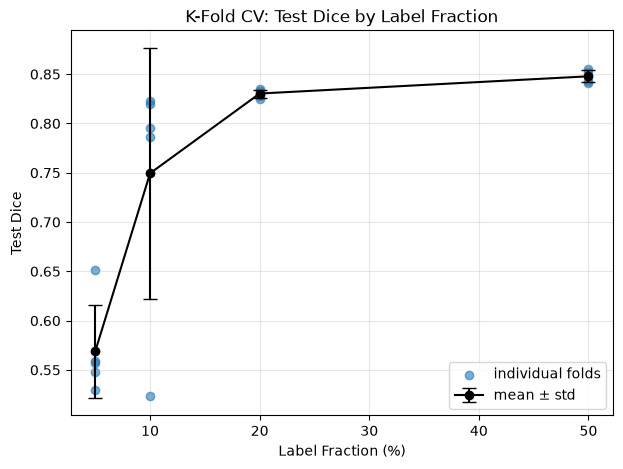


Ensemble results (one row per label fraction, averaged over its fold models):


,Dataset,Label Fraction (%),Folds Combined,Test Accuracy,Test Precision,Test Recall,Test MeanIoU,Test Dice,Test HD,Test MyIoU,Test MAE
0,ISIC2018,5,5,0.634750,0.440227,0.863863,0.460511,0.565705,10.515209,0.071142,0.365250
1,ISIC2018,10,5,0.892298,0.835248,0.792220,0.772241,0.811673,5.934208,0.481171,0.107702
2,ISIC2018,20,5,0.906083,0.885652,0.783741,0.794728,0.843473,5.609502,0.555019,0.093917
3,ISIC2018,50,5,0.915324,0.876874,0.830383,0.815709,0.860553,5.493648,0.548597,0.084676


Saved to results/ISIC2018_ensemble_results.csv

Ensemble vs. average single fold:


,Ensemble Test Dice,Avg Single-Fold Test Dice
Label Fraction (%),,
5,0.565705,0.568952
10,0.811673,0.749452
20,0.843473,0.830364
50,0.860553,0.847834


In [18]:
if USE_KFOLD and cv_results:
    cv_df = pd.DataFrame(cv_results)
    print("Per-fold results:")
    display(cv_df)

    # Mean +/- std across folds, per label fraction
    metric_cols = [c for c in cv_df.columns if c not in ("Dataset", "Label Fraction (%)", "Fold")]
    group_cols = [c for c in ("Dataset", "Label Fraction (%)") if c in cv_df.columns]
    cv_summary = cv_df.groupby(group_cols)[metric_cols].agg(['mean', 'std'])
    print("\nMean +/- std across folds:")
    display(cv_summary)

    os.makedirs("results", exist_ok=True)
    cv_df.to_csv(os.path.join("results", f"{DATASET_NAME}_cv_results.csv"), index=False)
    cv_summary.to_csv(os.path.join("results", f"{DATASET_NAME}_cv_summary.csv"))
    print(f"Saved to results/{DATASET_NAME}_cv_results.csv and results/{DATASET_NAME}_cv_summary.csv")

    # Sanity-check plot: Test Dice across folds per label fraction
    fractions_sorted = sorted(cv_df["Label Fraction (%)"].unique())
    plt.figure(figsize=(7, 5))
    for i, pct in enumerate(fractions_sorted):
        sub = cv_df[cv_df["Label Fraction (%)"] == pct]
        plt.scatter([pct] * len(sub), sub["Test Dice"], alpha=0.6, color='tab:blue',
                    label="individual folds" if i == 0 else None)
    means = cv_df.groupby("Label Fraction (%)")["Test Dice"].mean().loc[fractions_sorted]
    stds  = cv_df.groupby("Label Fraction (%)")["Test Dice"].std().loc[fractions_sorted]
    plt.errorbar(fractions_sorted, means.values, yerr=stds.values, fmt='o-',
                 color='black', capsize=5, label="mean ± std")
    plt.xlabel("Label Fraction (%)")
    plt.ylabel("Test Dice")
    plt.title("K-Fold CV: Test Dice by Label Fraction")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
else:
    cv_df = pd.DataFrame()

if USE_KFOLD and ensemble_results:
    ensemble_df = pd.DataFrame(ensemble_results)
    print("\nEnsemble results (one row per label fraction, averaged over its fold models):")
    display(ensemble_df)

    os.makedirs("results", exist_ok=True)
    ensemble_df.to_csv(os.path.join("results", f"{DATASET_NAME}_ensemble_results.csv"), index=False)
    print(f"Saved to results/{DATASET_NAME}_ensemble_results.csv")

    # Compare: single best fold's Test Dice (mean across folds) vs. the ensemble's Test Dice
    if not cv_df.empty:
        fold_mean_dice = cv_df.groupby("Label Fraction (%)")["Test Dice"].mean()
        compare_df = ensemble_df[["Label Fraction (%)", "Test Dice"]].rename(
            columns={"Test Dice": "Ensemble Test Dice"}
        ).set_index("Label Fraction (%)")
        compare_df["Avg Single-Fold Test Dice"] = fold_mean_dice
        print("\nEnsemble vs. average single fold:")
        display(compare_df)
else:
    ensemble_df = pd.DataFrame()


## Qualitative Visualisation

Loaded: saved_models/model_ISIC2018_BT-UNet_50pct_ensemble.keras


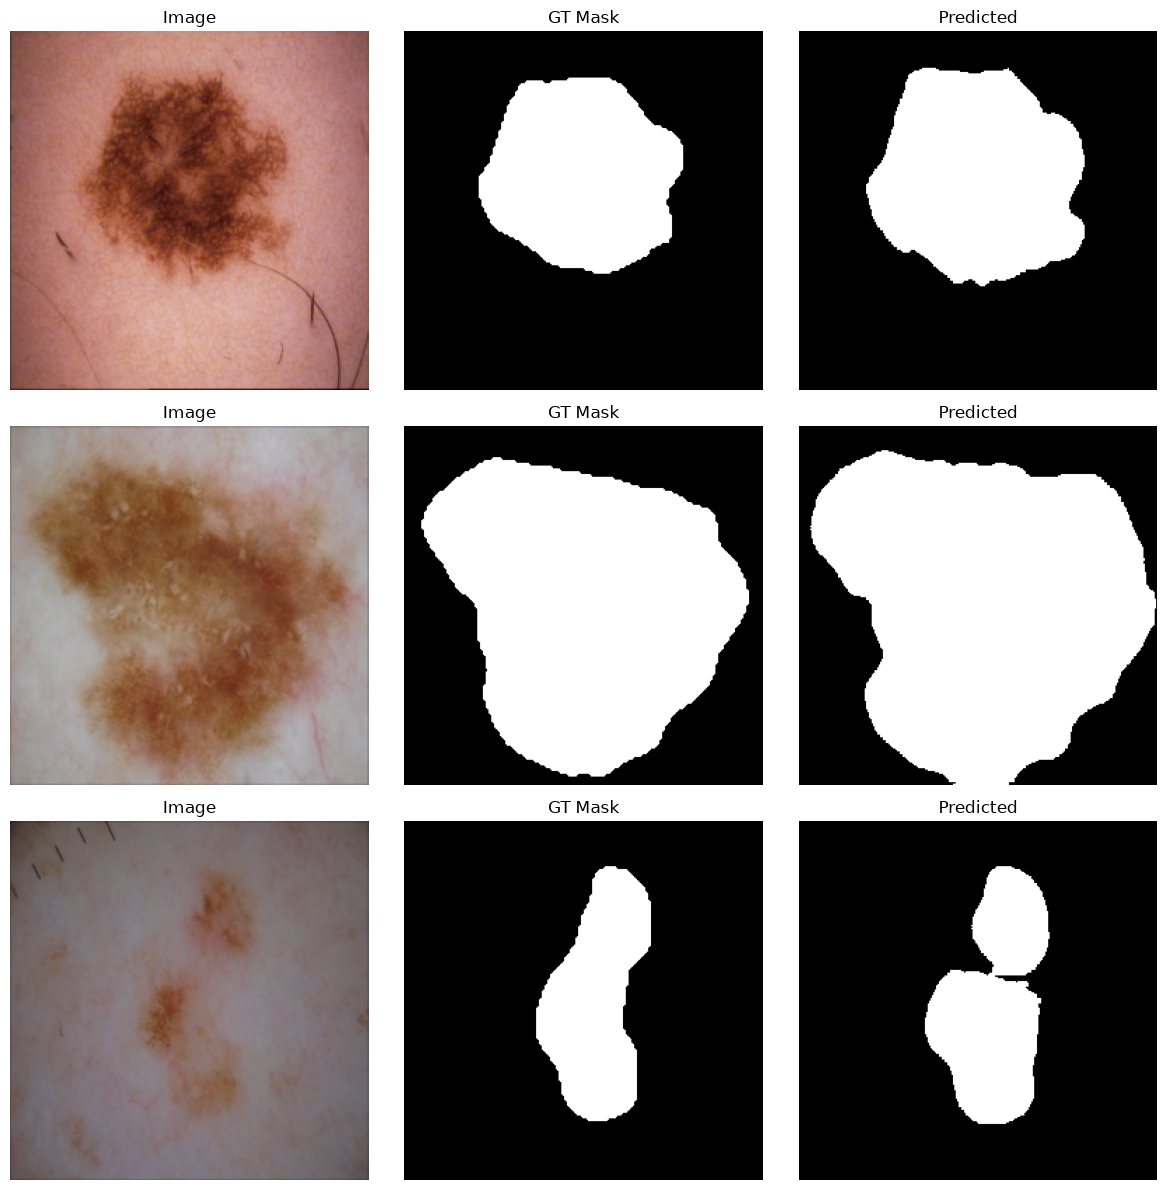

In [19]:
# Reload the best available model (50% fraction) for visualisation.
# Prefers the K-fold ensemble if one was built; falls back to the single-split
# model (e.g. if USE_KFOLD was False).
ensemble_path_vis = os.path.join(SAVE_DIR, f"model_{DATASET_NAME}_BT-UNet_50pct_ensemble.keras")
single_path_vis   = os.path.join(SAVE_DIR, f"model_{DATASET_NAME}_BT-UNet_50pct.keras")
model_path_vis    = ensemble_path_vis if os.path.exists(ensemble_path_vis) else single_path_vis

best_model = tf.keras.models.load_model(model_path_vis, compile=False)
print(f"Loaded: {model_path_vis}")
preds_test_vis = (best_model.predict(X_test, verbose=0) > THRESHOLD).astype(np.float32)

sample_idx = [0, 1, 2]
fig, axes  = plt.subplots(len(sample_idx), 3, figsize=(12, 4 * len(sample_idx)))
for row, ix in enumerate(sample_idx):
    axes[row, 0].imshow(X_test[ix].astype('uint8'));              axes[row, 0].set_title('Image');     axes[row, 0].axis('off')
    axes[row, 1].imshow(np.squeeze(Y_test[ix]), cmap='gray');     axes[row, 1].set_title('GT Mask');   axes[row, 1].axis('off')
    axes[row, 2].imshow(np.squeeze(preds_test_vis[ix]), cmap='gray'); axes[row, 2].set_title('Predicted'); axes[row, 2].axis('off')
plt.tight_layout()
plt.show()
